Filas y columnas originales: (82889, 24)
Filas tras limpieza: (82143, 24)


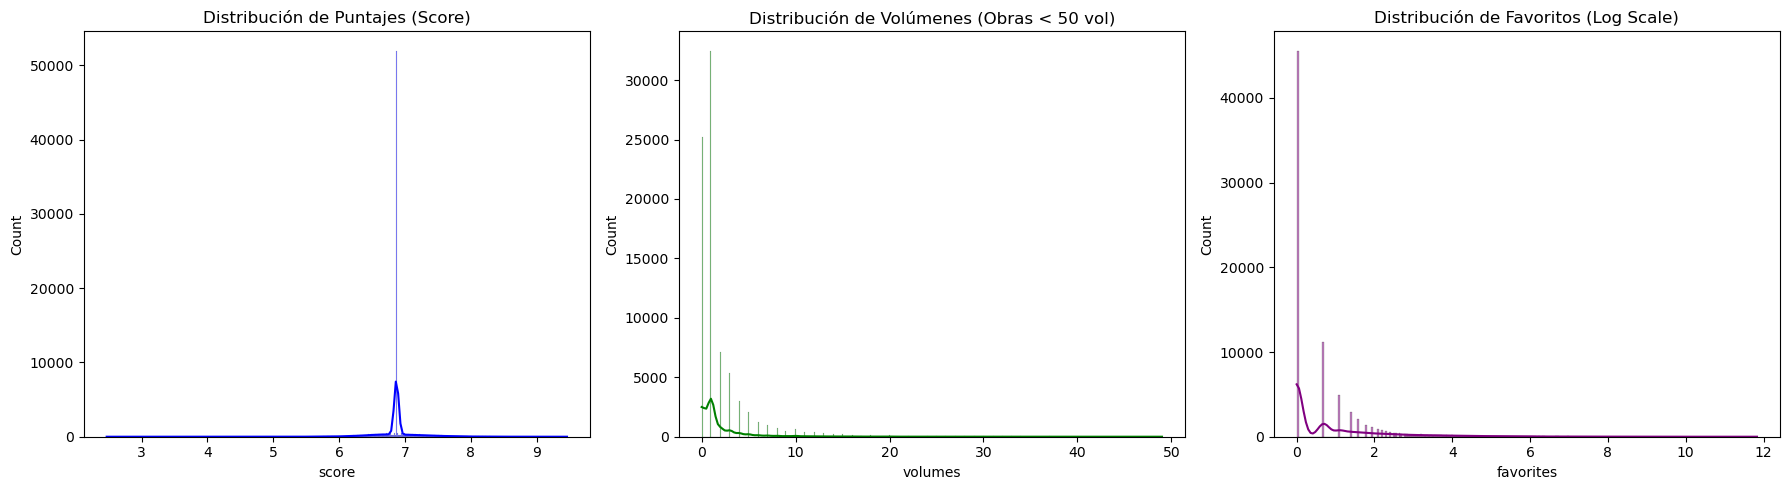

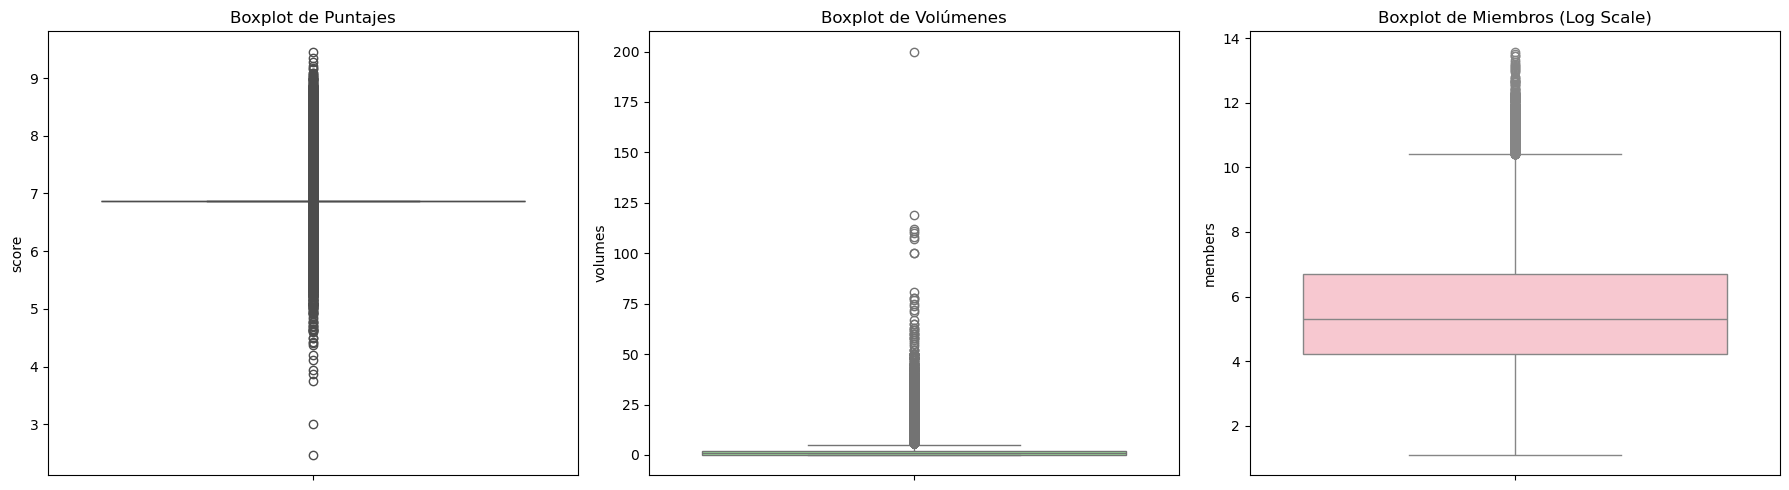

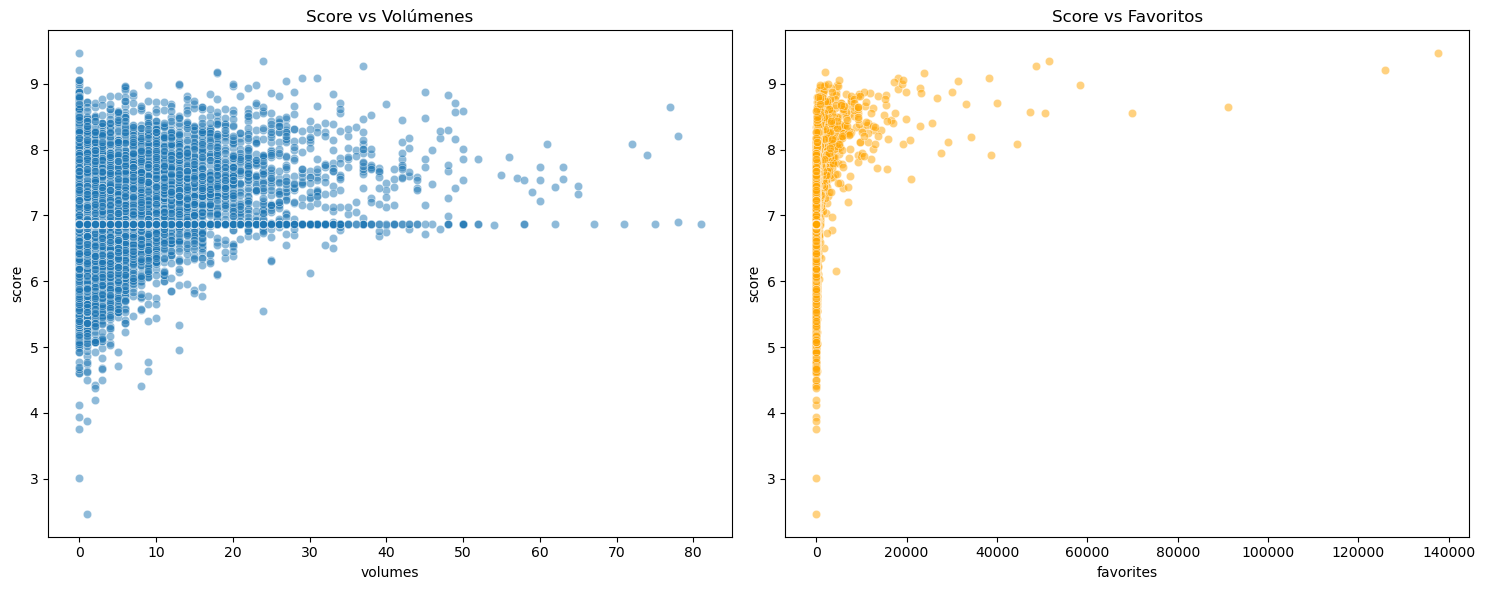

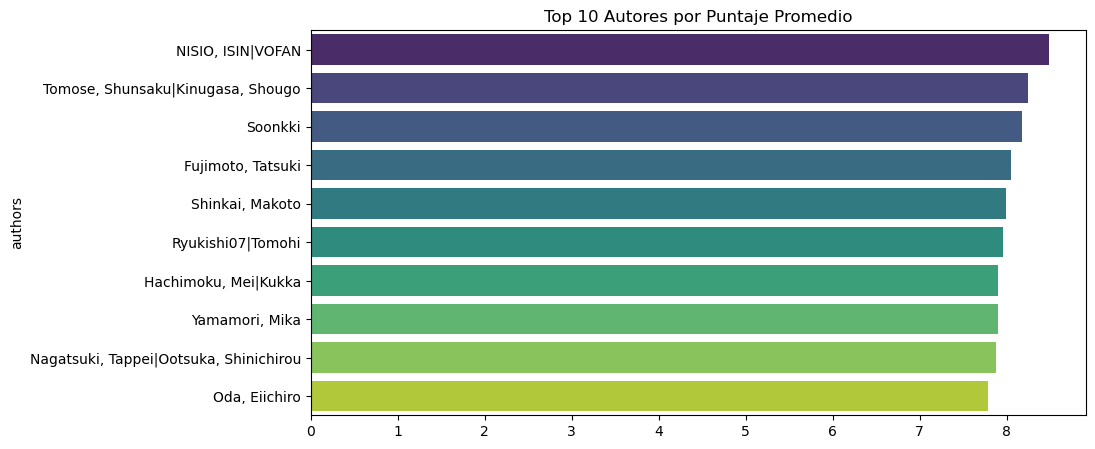

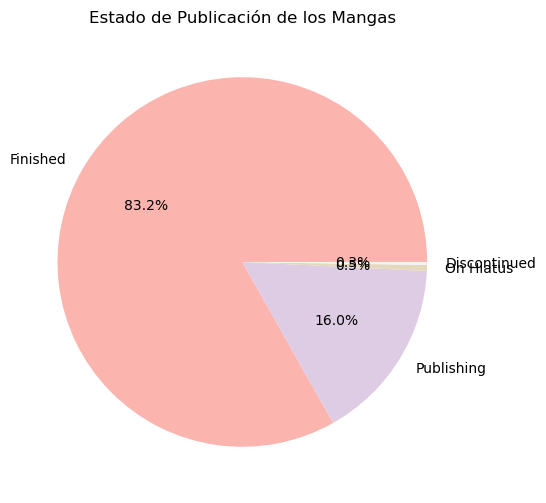

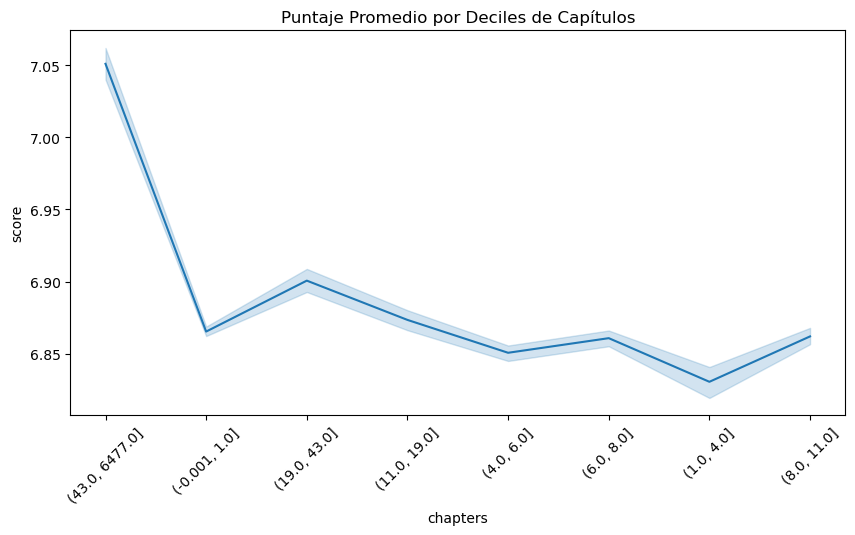

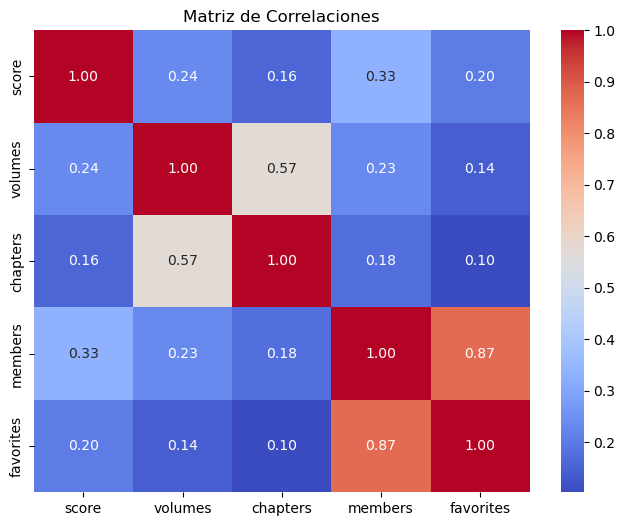

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. CARGA Y LIMPIEZA DE DATOS
# ==========================================
# Cargar el dataset (Asegurate de descargar el CSV de Kaggle y ponerle este nombre)
df = pd.read_csv('manga_dataset.csv')

# Verificar integridad, nulos y tipos de datos
print("Filas y columnas originales:", df.shape)
df = df.drop_duplicates() # Eliminar duplicados
df['score'] = pd.to_numeric(df['score'], errors='coerce') # Forzar tipo numérico

# Tratamiento de nulos: rellenamos numéricos con la mediana para no afectar distribuciones
df['score'] = df['score'].fillna(df['score'].median())
df['volumes'] = df['volumes'].fillna(0)
df['chapters'] = df['chapters'].fillna(0)
df.dropna(subset=['title', 'authors'], inplace=True) # Borrar nulos críticos

print("Filas tras limpieza:", df.shape)

# ==========================================
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================

# --- 3 Histogramas con KDE ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['score'], kde=True, ax=axes[0], color='blue').set_title('Distribución de Puntajes (Score)')
sns.histplot(df[df['volumes'] < 50]['volumes'], kde=True, ax=axes[1], color='green').set_title('Distribución de Volúmenes (Obras < 50 vol)')
sns.histplot(np.log1p(df['favorites']), kde=True, ax=axes[2], color='purple').set_title('Distribución de Favoritos (Log Scale)')
plt.tight_layout()
plt.show()

# --- 3 Boxplots (Detección de Atípicos) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['score'], ax=axes[0], color='cyan').set_title('Boxplot de Puntajes')
sns.boxplot(y=df['volumes'], ax=axes[1], color='lightgreen').set_title('Boxplot de Volúmenes')
sns.boxplot(y=np.log1p(df['members']), ax=axes[2], color='pink').set_title('Boxplot de Miembros (Log Scale)')
plt.tight_layout()
plt.show()

# --- 2 Scatterplots (Relación entre variables) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x='volumes', y='score', data=df[df['volumes'] < 100], ax=axes[0], alpha=0.5)
axes[0].set_title('Score vs Volúmenes')

sns.scatterplot(x='favorites', y='score', data=df, ax=axes[1], alpha=0.5, color='orange')
axes[1].set_title('Score vs Favoritos')
plt.tight_layout()
plt.show()

# --- 3 Visualizaciones Adicionales ---
# 1. Gráfico de Barras: Top 10 Autores por Score Promedio (Mínimo 5 obras)
top_authors = df.groupby('authors').filter(lambda x: len(x) >= 5)
top_authors = top_authors.groupby('authors')['score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, palette='viridis', legend=False)
plt.title('Top 10 Autores por Puntaje Promedio')
plt.show()

# 2. Gráfico de Torta: Proporción de Estados de Publicación
plt.figure(figsize=(6, 6))
df['status'].value_counts().head(4).plot.pie(autopct='%1.1f%%', cmap='Pastel1')
plt.title('Estado de Publicación de los Mangas')
plt.ylabel('')
plt.show()

# 3. Gráfico de Líneas: Evolución simulada de Score vs Capítulos
plt.figure(figsize=(10, 5))
sns.lineplot(x=pd.qcut(df['chapters'], q=10, duplicates='drop').astype(str), y=df['score'])
plt.xticks(rotation=45)
plt.title('Puntaje Promedio por Deciles de Capítulos')
plt.show()

# ==========================================
# MATRIZ DE CORRELACIÓN
# ==========================================
plt.figure(figsize=(8, 6))
corr = df[['score', 'volumes', 'chapters', 'members', 'favorites']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlaciones')
plt.show()

### Conclusiones y hallazgos relevantes

Tras el análisis exploratorio realizado sobre el dataset de mangas, se han podido extraer las siguientes conclusiones:

* **Correlación de Variables:** La matriz de correlación muestra una relación muy fuerte entre la cantidad de 'miembros' y los 'favoritos', lo que indica que cuanto más popular es un manga en términos de comunidad, más favorito es.
* **Estado de Publicación:** A través del gráfico de torta, observamos que la mayoría de los mangas en este dataset se encuentran en estado de 'Finished' (Finalizado), lo cual es coherente con la naturaleza de los datos.
* **Score y Capítulos:** Al analizar el puntaje promedio por deciles de capítulos, notamos que no siempre más capítulos significan un mejor score; existe un punto de equilibrio donde la calidad se mantiene sin necesidad de extender la obra innecesariamente.
* **Validación de hipótesis:** Los datos confirman que las obras con mayor base de usuarios ('members') tienden a concentrar la mayor cantidad de favoritos, validando la hipótesis de popularidad centralizada.